# Terna capacità rinnovabile 2015-2024 — analisi tecnica

**Dataset**: `terna_capacita_rinnovabile` (clean parquet su GCS)

**Periodo**: 2015-2024 (10 anni)

**Fonte**: Terna S.p.A.

Questo notebook analizza la capacità installata lorda (MW) per fonte rinnovabile.
Per la narrativa pubblica, vedi il [README](../README.md).

In [1]:
import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150})

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute("SET s3_region='us-east-1';")

GCS_PATH = 'gs://dataciviclab-clean/terna_capacita_rinnovabile/*/terna_capacita_rinnovabile_*_clean.parquet'

In [2]:
# 1. Verifica copertura
cov = con.execute(f'''
SELECT anno, tipo_capacita, COUNT(*) AS righe,
       COUNT(DISTINCT regione) AS regioni,
       COUNT(DISTINCT provincia) AS province
FROM read_parquet('{GCS_PATH}')
GROUP BY anno, tipo_capacita
ORDER BY anno, tipo_capacita
''').fetchdf()
cov

,anno,tipo_capacita,righe,regioni,province
0,2015,Lorda,534,20,111
1,2015,Netta,534,20,111
2,2016,Lorda,536,20,111
3,2016,Netta,536,20,111
4,2017,Lorda,554,20,107
5,2017,Netta,551,20,107
6,2018,Lorda,542,20,107
7,2018,Netta,542,20,107
8,2019,Lorda,563,20,107
9,2019,Netta,563,20,107


In [3]:
# 2. Capacità lorda per anno e fonte (MW)
df = con.execute(f'''
SELECT anno, fonti, ROUND(SUM(potenza_mw)) AS mw
FROM read_parquet('{GCS_PATH}')
WHERE tipo_capacita = 'Lorda'
GROUP BY anno, fonti
ORDER BY anno, fonti
''').fetchdf()

pivot = df.pivot_table(index='anno', columns='fonti', values='mw', aggfunc='sum').fillna(0).astype(int)
col_order = ['Fotovoltaico', 'Idrico', 'Eolico', 'Bioenergie', 'Geotermoelettrico']
col_order = [c for c in col_order if c in pivot.columns]
pivot = pivot[col_order]
pivot['totale'] = pivot[col_order].sum(axis=1)
pivot

fonti,Fotovoltaico,Idrico,Eolico,Bioenergie,Geotermoelettrico,totale
anno,,,,,,
2015,18901,18543,9162,4057,821,51484
2016,19283,18641,9410,4124,815,52273
2017,21940,19586,9960,4505,813,56804
2018,20108,18936,10265,4180,813,54302
2019,20865,18982,10715,4120,813,55495
2020,21650,19106,10907,4106,817,56586
2021,22594,19172,11290,4106,817,57979
2022,25064,19265,11858,4049,817,61053
2023,30319,19274,12336,4079,817,66825


### Nota
A differenza del dataset di produzione, la capacità installata **non ha anomalie nel 2017**.

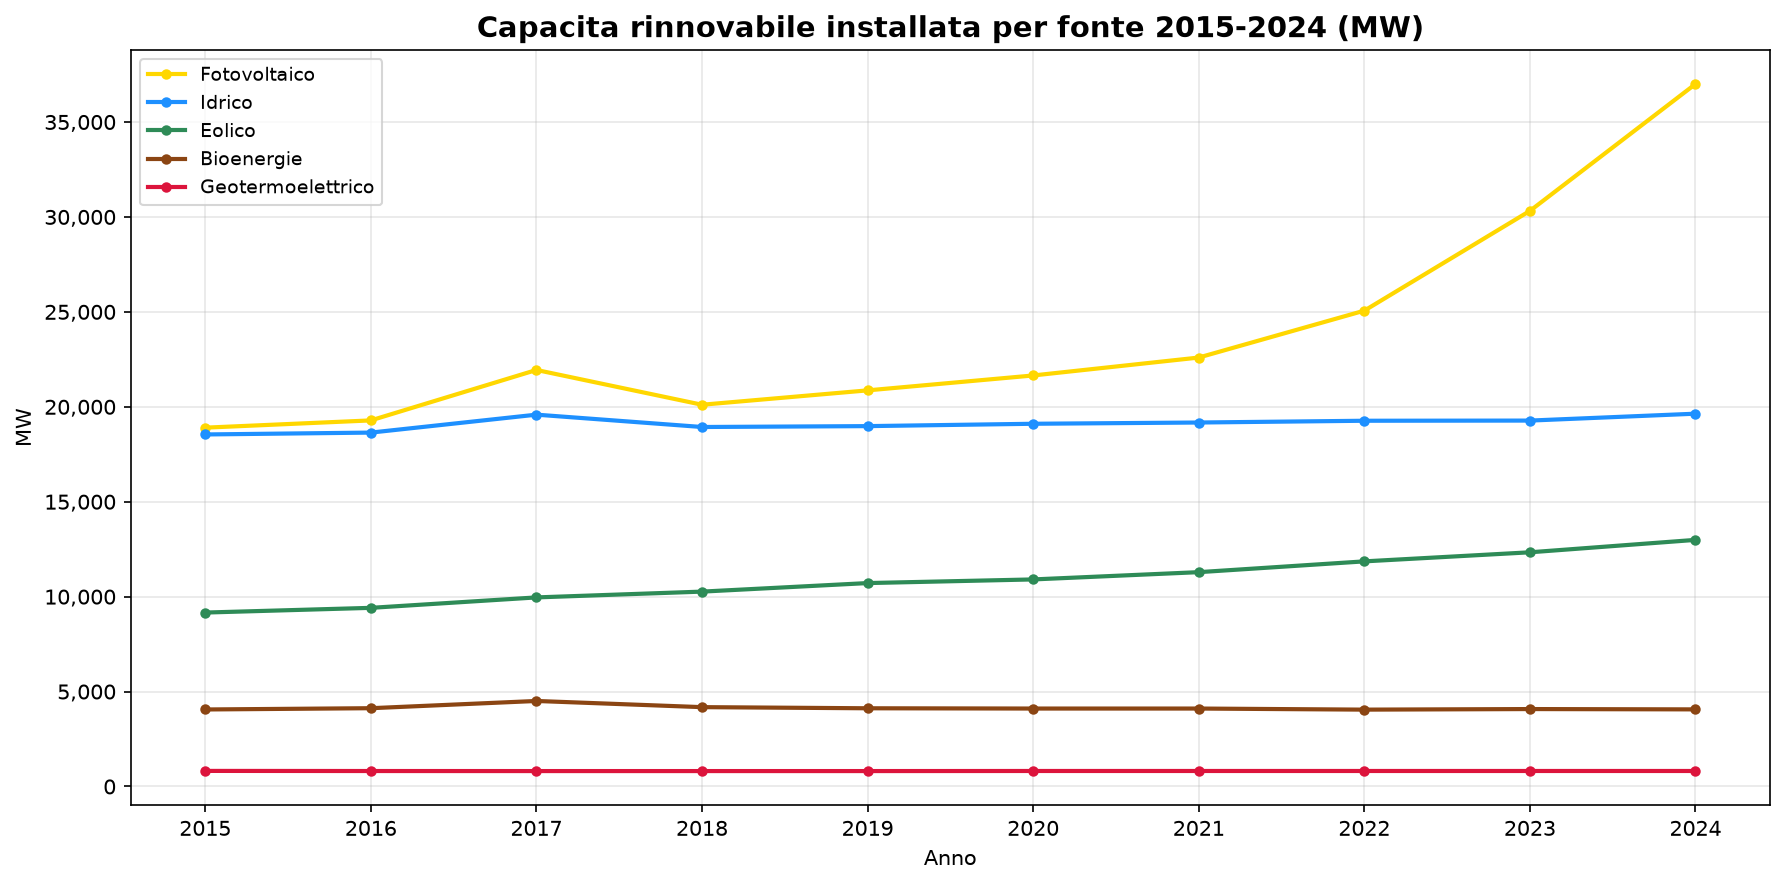

OK - terna_capacita_trend.png


In [4]:
# 3. Trend capacità per fonte
COLORI = {
    'Fotovoltaico': '#FFD700',
    'Idrico': '#1E90FF',
    'Eolico': '#2E8B57',
    'Bioenergie': '#8B4513',
    'Geotermoelettrico': '#DC143C',
}

fig, ax = plt.subplots(figsize=(12, 6))
anni = sorted(pivot.index)

for col in col_order:
    y = pivot[col].values
    ax.plot(anni, y, label=col, color=COLORI.get(col, '#333'),
            linewidth=2, marker='o', markersize=4)

ax.set_title('Capacita rinnovabile installata per fonte 2015-2024 (MW)', fontsize=14, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('MW')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(anni)
ax.set_xticklabels([str(a) for a in anni])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'terna_capacita_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_capacita_trend.png')

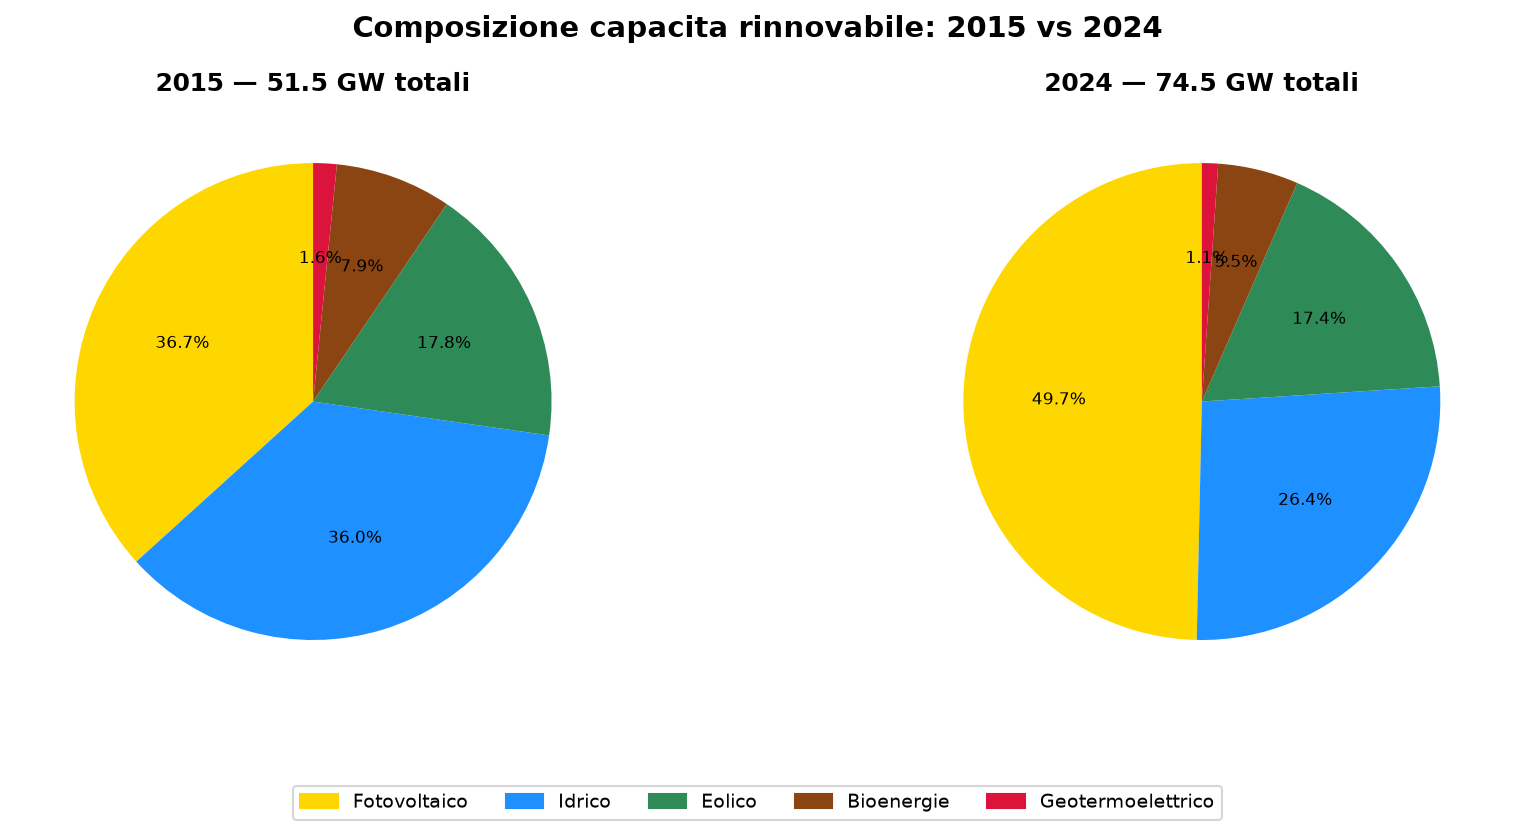

OK - terna_capacita_mix.png


In [5]:
# 4. Mix capacità 2015 vs 2024
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, anno in [(ax1, 2015), (ax2, 2024)]:
    row = pivot.loc[anno, col_order]
    labels = [c for c in col_order if row[c] > 0]
    sizes = [row[c] for c in labels]
    colors = [COLORI[c] for c in labels]
    ax.pie(sizes, labels=None, autopct='%1.1f%%',
           startangle=90, colors=colors, textprops={'fontsize': 8})
    tot_gw = pivot.loc[anno, 'totale'] / 1_000
    ax.set_title(f'{anno} — {tot_gw:.1f} GW totali',
                 fontsize=12, fontweight='bold')

fig.legend(
    [plt.Rectangle((0,0),1,1,color=COLORI[c]) for c in col_order],
    col_order, loc='lower center', ncol=len(col_order), fontsize=9
)
plt.suptitle('Composizione capacita rinnovabile: 2015 vs 2024', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(FIGURES_DIR / 'terna_capacita_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_capacita_mix.png')

Crescita media annua FV 2015-2021: 616 MW/anno
Crescita media annua FV 2021-2024: 4,803 MW/anno
Fattore di accelerazione: 8x


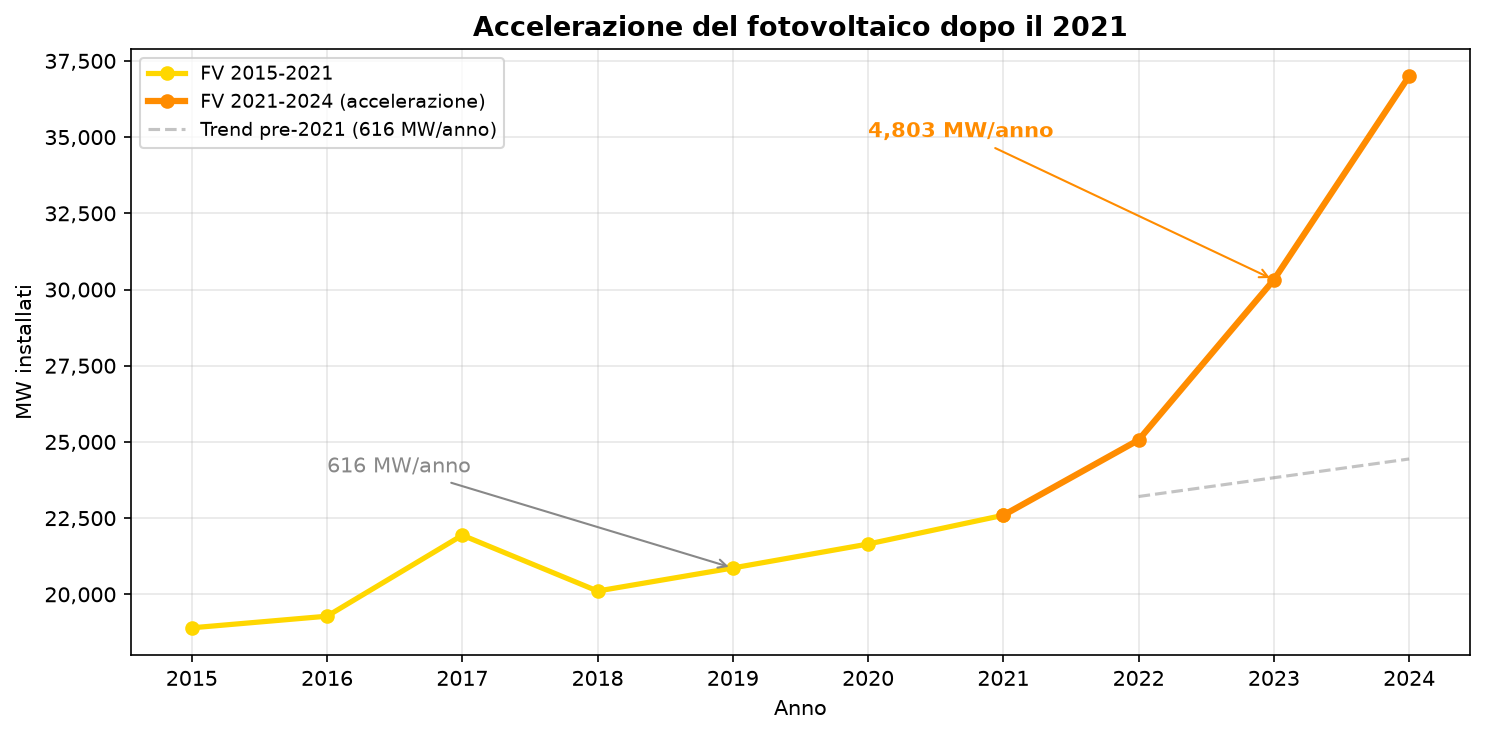

OK - terna_fv_accelerazione.png


In [6]:
# 5. Accelerazione FV: confronto pre/post 2021
fv = pivot['Fotovoltaico']
pre_2021 = fv.loc[:2021]
post_2021 = fv.loc[2021:]

acc_pre = (pre_2021.iloc[-1] - pre_2021.iloc[0]) / (len(pre_2021) - 1)
acc_post = (post_2021.iloc[-1] - post_2021.iloc[0]) / (len(post_2021) - 1)

print(f'Crescita media annua FV 2015-2021: {acc_pre:,.0f} MW/anno')
print(f'Crescita media annua FV 2021-2024: {acc_post:,.0f} MW/anno')
print(f'Fattore di accelerazione: {acc_post/acc_pre:.0f}x')

fig, ax = plt.subplots(figsize=(10, 5))
x_pre = pre_2021.index
x_post = post_2021.index

ax.plot(x_pre, pre_2021, 'o-', color='#FFD700', linewidth=2.5, label='FV 2015-2021')
ax.plot(x_post, post_2021, 'o-', color='#FF8C00', linewidth=3, label='FV 2021-2024 (accelerazione)')

# Linea trend pre-2021 estrapolata
slope = (pre_2021.iloc[-1] - pre_2021.iloc[0]) / (len(pre_2021) - 1)
extrapolated = [pre_2021.iloc[-1] + slope * i for i in range(1, 4)]
ax.plot([2022, 2023, 2024], extrapolated, '--', color='#888', alpha=0.5,
        label=f'Trend pre-2021 ({acc_pre:,.0f} MW/anno)')

ax.set_title('Accelerazione del fotovoltaico dopo il 2021', fontsize=13, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('MW installati')
ax.legend(fontsize=9)
ax.set_xticks(anni)
ax.set_xticklabels([str(a) for a in anni])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate(f'{acc_post:,.0f} MW/anno', xy=(2023, fv.loc[2023]),
            xytext=(2020, 35000), fontsize=10, color='#FF8C00', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#FF8C00'))
ax.annotate(f'{acc_pre:,.0f} MW/anno', xy=(2019, fv.loc[2019]),
            xytext=(2016, 24000), fontsize=10, color='#888',
            arrowprops=dict(arrowstyle='->', color='#888'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'terna_fv_accelerazione.png', dpi=150, bbox_inches='tight')
plt.show()
print('OK - terna_fv_accelerazione.png')

In [7]:
# 6. Top regioni per capacità FV 2024
reg = con.execute(f'''
SELECT regione, fonti, ROUND(SUM(potenza_mw)) AS mw
FROM read_parquet('{GCS_PATH}')
WHERE tipo_capacita = 'Lorda' AND anno = 2024
GROUP BY regione, fonti
ORDER BY mw DESC
''').fetchdf()

print('=== TOP 10 REGIONI per capacità FV 2024 ===')
top_fv = reg[reg.fonti == 'Fotovoltaico'].head(10)
for _, r in top_fv.iterrows():
    print(f"  {r['regione']:25s} {r['mw']:>6,} MW")

print(f"\n=== TOP 10 REGIONI per capacità EOLICA 2024 ===")
top_eol = reg[reg.fonti == 'Eolico'].head(10)
for _, r in top_eol.iterrows():
    print(f"  {r['regione']:25s} {r['mw']:>6,} MW")

print(f"\n=== TOTALE ITALIA per fonte 2024 ===")
tot_reg = reg.groupby('fonti')['mw'].sum().sort_values(ascending=False)
for f, m in tot_reg.items():
    print(f"  {f:25s} {m:>7,} MW")

=== TOP 10 REGIONI per capacità FV 2024 ===
  Lombardia                 4,959.0 MW
  Veneto                    3,748.0 MW
  Puglia                    3,627.0 MW
  Emilia-Romagna            3,574.0 MW
  Lazio                     3,295.0 MW
  Piemonte                  3,083.0 MW
  Sicilia                   2,674.0 MW
  Sardegna                  1,722.0 MW
  Campania                  1,525.0 MW
  Marche                    1,516.0 MW

=== TOP 10 REGIONI per capacità EOLICA 2024 ===
  Puglia                    3,235.0 MW
  Sicilia                   2,490.0 MW
  Campania                  2,177.0 MW
  Basilicata                1,505.0 MW
  Calabria                  1,249.0 MW
  Sardegna                  1,194.0 MW
  Molise                     407.0 MW
  Abruzzo                    274.0 MW
  Toscana                    144.0 MW
  Liguria                    134.0 MW

=== TOTALE ITALIA per fonte 2024 ===
  Fotovoltaico              37,003.0 MW
  Idrico                    19,637.0 MW
  Eolico     

In [8]:
# 7. Variazioni 2015 -> 2024
print('=' * 65)
print('VARIAZIONI CAPACITA 2015 -> 2024')
print('=' * 65)
for col in col_order:
    v15 = pivot.loc[2015, col]
    v24 = pivot.loc[2024, col]
    d = v24 - v15
    p = (d / v15 * 100) if v15 != 0 else float('inf')
    print(f'{col:25s} {v15:>6,} -> {v24:>6,} MW  ({d:+,} MW, {p:+.1f}%)')

print()
t15 = pivot.loc[2015, 'totale']
t24 = pivot.loc[2024, 'totale']
print(f'{"TOTALE":25s} {t15:>6,} -> {t24:>6,} MW  ({t24-t15:+,} MW, {(t24-t15)/t15*100:+.1f}%)')

VARIAZIONI CAPACITA 2015 -> 2024
Fotovoltaico              18,901 -> 37,002 MW  (+18,101 MW, +95.8%)
Idrico                    18,543 -> 19,637 MW  (+1,094 MW, +5.9%)
Eolico                     9,162 -> 12,990 MW  (+3,828 MW, +41.8%)
Bioenergie                 4,057 ->  4,062 MW  (+5 MW, +0.1%)
Geotermoelettrico            821 ->    817 MW  (-4 MW, -0.5%)

TOTALE                    51,484 -> 74,508 MW  (+23,024 MW, +44.7%)


In [9]:
# 8. Cleanup
con.close()
print('Connessione chiusa.')
print('Figure:', sorted([p.name for p in FIGURES_DIR.glob('*.png')]))

Connessione chiusa.
Figure: ['terna_capacita_mix.png', 'terna_capacita_trend.png', 'terna_fv_accelerazione.png']
